# Laptop Price Prediction

This project is a machine learning study that aims to predict the price of laptops based on their technical specifications using the laptop.csv dataset.

In [1]:
import pandas as pd
import re
import math

In [2]:
df=pd.read_csv('laptop_data.csv', index_col=0)

In [3]:
df

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080
...,...,...,...,...,...,...,...,...,...,...,...
1298,Lenovo,2 in 1 Convertible,14.0,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 6500U 2.5GHz,4GB,128GB SSD,Intel HD Graphics 520,Windows 10,1.8kg,33992.6400
1299,Lenovo,2 in 1 Convertible,13.3,IPS Panel Quad HD+ / Touchscreen 3200x1800,Intel Core i7 6500U 2.5GHz,16GB,512GB SSD,Intel HD Graphics 520,Windows 10,1.3kg,79866.7200
1300,Lenovo,Notebook,14.0,1366x768,Intel Celeron Dual Core N3050 1.6GHz,2GB,64GB Flash Storage,Intel HD Graphics,Windows 10,1.5kg,12201.1200
1301,HP,Notebook,15.6,1366x768,Intel Core i7 6500U 2.5GHz,6GB,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19kg,40705.9200


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1303 entries, 0 to 1302
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1303 non-null   object 
 1   TypeName          1303 non-null   object 
 2   Inches            1303 non-null   float64
 3   ScreenResolution  1303 non-null   object 
 4   Cpu               1303 non-null   object 
 5   Ram               1303 non-null   object 
 6   Memory            1303 non-null   object 
 7   Gpu               1303 non-null   object 
 8   OpSys             1303 non-null   object 
 9   Weight            1303 non-null   object 
 10  Price             1303 non-null   float64
dtypes: float64(2), object(9)
memory usage: 122.2+ KB


In [5]:
df.isnull().sum()

Company             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price               0
dtype: int64

In [6]:
df['Company'].value_counts()

Company
Dell         297
Lenovo       297
HP           274
Asus         158
Acer         103
MSI           54
Toshiba       48
Apple         21
Samsung        9
Mediacom       7
Razer          7
Microsoft      6
Vero           4
Xiaomi         4
Chuwi          3
Fujitsu        3
Google         3
LG             3
Huawei         2
Name: count, dtype: int64

In [7]:
# outlier : Huawei, LG, Google..

In [8]:
df['TypeName'].value_counts()

TypeName
Notebook              727
Gaming                205
Ultrabook             196
2 in 1 Convertible    121
Workstation            29
Netbook                25
Name: count, dtype: int64

In [9]:
df.TypeName.value_counts()

TypeName
Notebook              727
Gaming                205
Ultrabook             196
2 in 1 Convertible    121
Workstation            29
Netbook                25
Name: count, dtype: int64

In [10]:
df.ScreenResolution.value_counts()

ScreenResolution
Full HD 1920x1080                                507
1366x768                                         281
IPS Panel Full HD 1920x1080                      230
IPS Panel Full HD / Touchscreen 1920x1080         53
Full HD / Touchscreen 1920x1080                   47
1600x900                                          23
Touchscreen 1366x768                              16
Quad HD+ / Touchscreen 3200x1800                  15
IPS Panel 4K Ultra HD 3840x2160                   12
IPS Panel 4K Ultra HD / Touchscreen 3840x2160     11
4K Ultra HD / Touchscreen 3840x2160               10
IPS Panel 1366x768                                 7
Touchscreen 2560x1440                              7
4K Ultra HD 3840x2160                              7
IPS Panel Retina Display 2304x1440                 6
IPS Panel Retina Display 2560x1600                 6
Touchscreen 2256x1504                              6
IPS Panel Quad HD+ / Touchscreen 3200x1800         6
IPS Panel Touchscreen 2560x14

In [11]:
def extract_resolution(resolition_string):
    match=re.search(r'(\d+x\d+)', resolition_string)
    return match.group(1) if match else None

In [12]:
df['Resolition']=df['ScreenResolution'].apply(extract_resolution)

In [13]:
df

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Resolition
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832,2560x1600
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232,1440x900
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000,1920x1080
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360,2880x1800
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080,2560x1600
...,...,...,...,...,...,...,...,...,...,...,...,...
1298,Lenovo,2 in 1 Convertible,14.0,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 6500U 2.5GHz,4GB,128GB SSD,Intel HD Graphics 520,Windows 10,1.8kg,33992.6400,1920x1080
1299,Lenovo,2 in 1 Convertible,13.3,IPS Panel Quad HD+ / Touchscreen 3200x1800,Intel Core i7 6500U 2.5GHz,16GB,512GB SSD,Intel HD Graphics 520,Windows 10,1.3kg,79866.7200,3200x1800
1300,Lenovo,Notebook,14.0,1366x768,Intel Celeron Dual Core N3050 1.6GHz,2GB,64GB Flash Storage,Intel HD Graphics,Windows 10,1.5kg,12201.1200,1366x768
1301,HP,Notebook,15.6,1366x768,Intel Core i7 6500U 2.5GHz,6GB,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19kg,40705.9200,1366x768


In [14]:
df.Cpu.value_counts()

Cpu
Intel Core i5 7200U 2.5GHz       190
Intel Core i7 7700HQ 2.8GHz      146
Intel Core i7 7500U 2.7GHz       134
Intel Core i7 8550U 1.8GHz        73
Intel Core i5 8250U 1.6GHz        72
                                ... 
Intel Core i5 7200U 2.70GHz        1
Intel Core M M7-6Y75 1.2GHz        1
Intel Core M 6Y54 1.1GHz           1
AMD E-Series 9000 2.2GHz           1
Samsung Cortex A72&A53 2.0GHz      1
Name: count, Length: 118, dtype: int64

In [15]:
def extract_ghz(cpu_string):
    match=re.search(r'(\d+(\.\d+)?)GHz', cpu_string)
    return float(match.group(1)) if match else None

In [16]:
df['GHz']=df['Cpu'].apply(extract_ghz)

In [17]:
df

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Resolition,GHz
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832,2560x1600,2.3
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232,1440x900,1.8
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000,1920x1080,2.5
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360,2880x1800,2.7
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080,2560x1600,3.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1298,Lenovo,2 in 1 Convertible,14.0,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 6500U 2.5GHz,4GB,128GB SSD,Intel HD Graphics 520,Windows 10,1.8kg,33992.6400,1920x1080,2.5
1299,Lenovo,2 in 1 Convertible,13.3,IPS Panel Quad HD+ / Touchscreen 3200x1800,Intel Core i7 6500U 2.5GHz,16GB,512GB SSD,Intel HD Graphics 520,Windows 10,1.3kg,79866.7200,3200x1800,2.5
1300,Lenovo,Notebook,14.0,1366x768,Intel Celeron Dual Core N3050 1.6GHz,2GB,64GB Flash Storage,Intel HD Graphics,Windows 10,1.5kg,12201.1200,1366x768,1.6
1301,HP,Notebook,15.6,1366x768,Intel Core i7 6500U 2.5GHz,6GB,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19kg,40705.9200,1366x768,2.5


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1303 entries, 0 to 1302
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1303 non-null   object 
 1   TypeName          1303 non-null   object 
 2   Inches            1303 non-null   float64
 3   ScreenResolution  1303 non-null   object 
 4   Cpu               1303 non-null   object 
 5   Ram               1303 non-null   object 
 6   Memory            1303 non-null   object 
 7   Gpu               1303 non-null   object 
 8   OpSys             1303 non-null   object 
 9   Weight            1303 non-null   object 
 10  Price             1303 non-null   float64
 11  Resolition        1303 non-null   object 
 12  GHz               1303 non-null   float64
dtypes: float64(3), object(10)
memory usage: 142.5+ KB


In [19]:
df.Ram.value_counts()

Ram
8GB     619
4GB     375
16GB    200
6GB      41
12GB     25
2GB      22
32GB     17
24GB      3
64GB      1
Name: count, dtype: int64

In [20]:
df['Ram']=df['Ram'].str.replace('GB','').astype("int32")

In [21]:
df

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Resolition,GHz
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832,2560x1600,2.3
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232,1440x900,1.8
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000,1920x1080,2.5
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360,2880x1800,2.7
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080,2560x1600,3.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1298,Lenovo,2 in 1 Convertible,14.0,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 6500U 2.5GHz,4,128GB SSD,Intel HD Graphics 520,Windows 10,1.8kg,33992.6400,1920x1080,2.5
1299,Lenovo,2 in 1 Convertible,13.3,IPS Panel Quad HD+ / Touchscreen 3200x1800,Intel Core i7 6500U 2.5GHz,16,512GB SSD,Intel HD Graphics 520,Windows 10,1.3kg,79866.7200,3200x1800,2.5
1300,Lenovo,Notebook,14.0,1366x768,Intel Celeron Dual Core N3050 1.6GHz,2,64GB Flash Storage,Intel HD Graphics,Windows 10,1.5kg,12201.1200,1366x768,1.6
1301,HP,Notebook,15.6,1366x768,Intel Core i7 6500U 2.5GHz,6,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19kg,40705.9200,1366x768,2.5


In [22]:
df.Memory.value_counts()

Memory
256GB SSD                        412
1TB HDD                          223
500GB HDD                        132
512GB SSD                        118
128GB SSD +  1TB HDD              94
128GB SSD                         76
256GB SSD +  1TB HDD              73
32GB Flash Storage                38
2TB HDD                           16
64GB Flash Storage                15
1TB SSD                           14
512GB SSD +  1TB HDD              14
256GB SSD +  2TB HDD              10
1.0TB Hybrid                       9
256GB Flash Storage                8
16GB Flash Storage                 7
32GB SSD                           6
180GB SSD                          5
128GB Flash Storage                4
16GB SSD                           3
512GB SSD +  2TB HDD               3
128GB SSD +  2TB HDD               2
256GB SSD +  256GB SSD             2
512GB Flash Storage                2
1TB SSD +  1TB HDD                 2
256GB SSD +  500GB HDD             2
64GB SSD                       

In [23]:
df['Memory']=df['Memory'].str.replace('2TB','2048GB')
df['Memory']=df['Memory'].str.replace('1TB','1024GB')
df['Memory']=df['Memory'].str.replace('1.0TB','1024GB')

In [24]:
df.Memory.value_counts()

Memory
256GB SSD                           412
1024GB HDD                          224
500GB HDD                           132
512GB SSD                           118
128GB SSD +  1024GB HDD              94
128GB SSD                            76
256GB SSD +  1024GB HDD              73
32GB Flash Storage                   38
2048GB HDD                           16
64GB Flash Storage                   15
512GB SSD +  1024GB HDD              14
1024GB SSD                           14
256GB SSD +  2048GB HDD              10
1024GB Hybrid                         9
256GB Flash Storage                   8
16GB Flash Storage                    7
32GB SSD                              6
180GB SSD                             5
128GB Flash Storage                   4
512GB SSD +  2048GB HDD               3
16GB SSD                              3
256GB SSD +  256GB SSD                2
512GB Flash Storage                   2
1024GB SSD +  1024GB HDD              2
256GB SSD +  500GB HDD           

In [25]:
df['SSD']=0
df['HDD']=0
df['Flash_Storage']=0
df['Hybrid']=0

In [26]:
df['Memory']=df['Memory'].str.replace("1024GB HDD +  1024GB HDD","2048GB HDD")
df['Memory']=df['Memory'].str.replace("512GB SSD +  256GB SSD","768GB SSD")
df['Memory']=df['Memory'].str.replace("256GB SSD +  256GB SSD","512GB SSD")
df['Memory']=df['Memory'].str.replace("512GB SSD +  512GB SSD","1024GB SSD")

In [27]:
df.Memory.value_counts()

Memory
256GB SSD                           412
1024GB HDD                          224
500GB HDD                           132
512GB SSD                           120
128GB SSD +  1024GB HDD              94
128GB SSD                            76
256GB SSD +  1024GB HDD              73
32GB Flash Storage                   38
2048GB HDD                           17
1024GB SSD                           15
64GB Flash Storage                   15
512GB SSD +  1024GB HDD              14
256GB SSD +  2048GB HDD              10
1024GB Hybrid                         9
256GB Flash Storage                   8
16GB Flash Storage                    7
32GB SSD                              6
180GB SSD                             5
128GB Flash Storage                   4
512GB SSD +  2048GB HDD               3
16GB SSD                              3
128GB SSD +  2048GB HDD               2
256GB SSD +  500GB HDD                2
512GB Flash Storage                   2
1024GB SSD +  1024GB HDD         

In [28]:
def extract_memory(memory_string):
    if 'SSD' in memory_string:
        size_match= re.search(r'\b(\d+)GB\s+SSD\b', memory_string)
        if size_match:
            df.loc[df['Memory'] == memory_string, 'SSD'] = size_match.group(1)

    if 'HDD' in memory_string:
        size_match= re.search(r'\b(\d+)GB\s+HDD\b', memory_string)
        if size_match:
            df.loc[df['Memory'] == memory_string, 'HDD'] = size_match.group(1)

    
    if 'Flash Storage' in memory_string:
        size_match= re.search(r'\b(\d+)GB\s+Flash Storage\b', memory_string)
        if size_match:
            df.loc[df['Memory'] == memory_string, 'Flash_Storage'] = size_match.group(1)       

    if 'Hybrid' in memory_string:
        size_match= re.search(r'\b(\d+)GB\s+Hybrid\b', memory_string)
        if size_match:
            df.loc[df['Memory'] == memory_string, 'Hybrid'] = size_match.group(1) 

In [29]:
for memory in df['Memory']:
    extract_memory(memory)

C:\Users\kosey\AppData\Local\Temp\ipykernel_30748\1298150961.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '128' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df['Memory'] == memory_string, 'SSD'] = size_match.group(1)
C:\Users\kosey\AppData\Local\Temp\ipykernel_30748\1298150961.py:16: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '128' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df['Memory'] == memory_string, 'Flash_Storage'] = size_match.group(1)
C:\Users\kosey\AppData\Local\Temp\ipykernel_30748\1298150961.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '500' has dtype incompatible with int64, please explicitly cast to a compatible

In [30]:
df

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Resolition,GHz,SSD,HDD,Flash_Storage,Hybrid
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832,2560x1600,2.3,128,0,0,0
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232,1440x900,1.8,0,0,128,0
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000,1920x1080,2.5,256,0,0,0
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360,2880x1800,2.7,512,0,0,0
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080,2560x1600,3.1,256,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1298,Lenovo,2 in 1 Convertible,14.0,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 6500U 2.5GHz,4,128GB SSD,Intel HD Graphics 520,Windows 10,1.8kg,33992.6400,1920x1080,2.5,128,0,0,0
1299,Lenovo,2 in 1 Convertible,13.3,IPS Panel Quad HD+ / Touchscreen 3200x1800,Intel Core i7 6500U 2.5GHz,16,512GB SSD,Intel HD Graphics 520,Windows 10,1.3kg,79866.7200,3200x1800,2.5,512,0,0,0
1300,Lenovo,Notebook,14.0,1366x768,Intel Celeron Dual Core N3050 1.6GHz,2,64GB Flash Storage,Intel HD Graphics,Windows 10,1.5kg,12201.1200,1366x768,1.6,0,0,64,0
1301,HP,Notebook,15.6,1366x768,Intel Core i7 6500U 2.5GHz,6,1024GB HDD,AMD Radeon R5 M330,Windows 10,2.19kg,40705.9200,1366x768,2.5,0,1024,0,0


In [31]:
df.head(50)

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Resolition,GHz,SSD,HDD,Flash_Storage,Hybrid
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832,2560x1600,2.30,128,0,0,0
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232,1440x900,1.80,0,0,128,0
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000,1920x1080,2.50,256,0,0,0
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360,2880x1800,2.70,512,0,0,0
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080,2560x1600,3.10,256,0,0,0
5,Acer,Notebook,15.6,1366x768,AMD A9-Series 9420 3GHz,4,500GB HDD,AMD Radeon R5,Windows 10,2.1kg,21312.0000,1366x768,3.00,0,500,0,0
6,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.2GHz,16,256GB Flash Storage,Intel Iris Pro Graphics,Mac OS X,2.04kg,114017.6016,2880x1800,2.20,0,0,256,0
7,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,256GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,61735.5360,1440x900,1.80,0,0,256,0
8,Asus,Ultrabook,14.0,Full HD 1920x1080,Intel Core i7 8550U 1.8GHz,16,512GB SSD,Nvidia GeForce MX150,Windows 10,1.3kg,79653.6000,1920x1080,1.80,512,0,0,0
9,Acer,Ultrabook,14.0,IPS Panel Full HD 1920x1080,Intel Core i5 8250U 1.6GHz,8,256GB SSD,Intel UHD Graphics 620,Windows 10,1.6kg,41025.6000,1920x1080,1.60,256,0,0,0


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1303 entries, 0 to 1302
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1303 non-null   object 
 1   TypeName          1303 non-null   object 
 2   Inches            1303 non-null   float64
 3   ScreenResolution  1303 non-null   object 
 4   Cpu               1303 non-null   object 
 5   Ram               1303 non-null   int32  
 6   Memory            1303 non-null   object 
 7   Gpu               1303 non-null   object 
 8   OpSys             1303 non-null   object 
 9   Weight            1303 non-null   object 
 10  Price             1303 non-null   float64
 11  Resolition        1303 non-null   object 
 12  GHz               1303 non-null   float64
 13  SSD               1303 non-null   object 
 14  HDD               1303 non-null   object 
 15  Flash_Storage     1303 non-null   object 
 16  Hybrid            1303 non-null   object 
dtype

In [33]:
df['SSD']=df['SSD'].astype('int32')
df['HDD']=df['HDD'].astype('int32')
df['Flash_Storage']=df['Flash_Storage'].astype('int32')
df['Hybrid']=df['Hybrid'].astype('int32')

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1303 entries, 0 to 1302
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1303 non-null   object 
 1   TypeName          1303 non-null   object 
 2   Inches            1303 non-null   float64
 3   ScreenResolution  1303 non-null   object 
 4   Cpu               1303 non-null   object 
 5   Ram               1303 non-null   int32  
 6   Memory            1303 non-null   object 
 7   Gpu               1303 non-null   object 
 8   OpSys             1303 non-null   object 
 9   Weight            1303 non-null   object 
 10  Price             1303 non-null   float64
 11  Resolition        1303 non-null   object 
 12  GHz               1303 non-null   float64
 13  SSD               1303 non-null   int32  
 14  HDD               1303 non-null   int32  
 15  Flash_Storage     1303 non-null   int32  
 16  Hybrid            1303 non-null   int32  
dtype

In [35]:
df.isnull().sum()

Company             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price               0
Resolition          0
GHz                 0
SSD                 0
HDD                 0
Flash_Storage       0
Hybrid              0
dtype: int64

In [36]:
df['OpSys'].value_counts()

OpSys
Windows 10      1072
No OS             66
Linux             62
Windows 7         45
Chrome OS         27
macOS             13
Mac OS X           8
Windows 10 S       8
Android            2
Name: count, dtype: int64

In [37]:
df['OpSys']=df['OpSys'].replace('Windows 10 S','Windows 10')
df['OpSys']=df['OpSys'].replace('Mac OS X','macOS')

In [38]:
df['OpSys'].value_counts()

OpSys
Windows 10    1080
No OS           66
Linux           62
Windows 7       45
Chrome OS       27
macOS           21
Android          2
Name: count, dtype: int64

In [39]:
df['Weight']=df['Weight'].str.rstrip("kg").astype(float)

In [40]:
df

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Resolition,GHz,SSD,HDD,Flash_Storage,Hybrid
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,2560x1600,2.3,128,0,0,0
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,1440x900,1.8,0,0,128,0
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,1920x1080,2.5,256,0,0,0
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,2880x1800,2.7,512,0,0,0
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,2560x1600,3.1,256,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1298,Lenovo,2 in 1 Convertible,14.0,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 6500U 2.5GHz,4,128GB SSD,Intel HD Graphics 520,Windows 10,1.80,33992.6400,1920x1080,2.5,128,0,0,0
1299,Lenovo,2 in 1 Convertible,13.3,IPS Panel Quad HD+ / Touchscreen 3200x1800,Intel Core i7 6500U 2.5GHz,16,512GB SSD,Intel HD Graphics 520,Windows 10,1.30,79866.7200,3200x1800,2.5,512,0,0,0
1300,Lenovo,Notebook,14.0,1366x768,Intel Celeron Dual Core N3050 1.6GHz,2,64GB Flash Storage,Intel HD Graphics,Windows 10,1.50,12201.1200,1366x768,1.6,0,0,64,0
1301,HP,Notebook,15.6,1366x768,Intel Core i7 6500U 2.5GHz,6,1024GB HDD,AMD Radeon R5 M330,Windows 10,2.19,40705.9200,1366x768,2.5,0,1024,0,0


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1303 entries, 0 to 1302
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1303 non-null   object 
 1   TypeName          1303 non-null   object 
 2   Inches            1303 non-null   float64
 3   ScreenResolution  1303 non-null   object 
 4   Cpu               1303 non-null   object 
 5   Ram               1303 non-null   int32  
 6   Memory            1303 non-null   object 
 7   Gpu               1303 non-null   object 
 8   OpSys             1303 non-null   object 
 9   Weight            1303 non-null   float64
 10  Price             1303 non-null   float64
 11  Resolition        1303 non-null   object 
 12  GHz               1303 non-null   float64
 13  SSD               1303 non-null   int32  
 14  HDD               1303 non-null   int32  
 15  Flash_Storage     1303 non-null   int32  
 16  Hybrid            1303 non-null   int32  
dtype

In [42]:
def calculate_ppi(resolution, diagonal):
    width, height = map(int, resolution.split('x'))
    diagonal_pixels = math.sqrt(width**2 + height**2)
    ppi = diagonal_pixels / diagonal
    return ppi
df['PPI'] = df.apply(lambda row: calculate_ppi(row['Resolition'], row['Inches']), axis=1)

In [43]:
df

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Resolition,GHz,SSD,HDD,Flash_Storage,Hybrid,PPI
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,2560x1600,2.3,128,0,0,0,226.983005
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,1440x900,1.8,0,0,128,0,127.677940
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,1920x1080,2.5,256,0,0,0,141.211998
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,2880x1800,2.7,512,0,0,0,220.534624
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,2560x1600,3.1,256,0,0,0,226.983005
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1298,Lenovo,2 in 1 Convertible,14.0,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 6500U 2.5GHz,4,128GB SSD,Intel HD Graphics 520,Windows 10,1.80,33992.6400,1920x1080,2.5,128,0,0,0,157.350512
1299,Lenovo,2 in 1 Convertible,13.3,IPS Panel Quad HD+ / Touchscreen 3200x1800,Intel Core i7 6500U 2.5GHz,16,512GB SSD,Intel HD Graphics 520,Windows 10,1.30,79866.7200,3200x1800,2.5,512,0,0,0,276.053530
1300,Lenovo,Notebook,14.0,1366x768,Intel Celeron Dual Core N3050 1.6GHz,2,64GB Flash Storage,Intel HD Graphics,Windows 10,1.50,12201.1200,1366x768,1.6,0,0,64,0,111.935204
1301,HP,Notebook,15.6,1366x768,Intel Core i7 6500U 2.5GHz,6,1024GB HDD,AMD Radeon R5 M330,Windows 10,2.19,40705.9200,1366x768,2.5,0,1024,0,0,100.454670


In [44]:
df.select_dtypes(include='number').corr()

,Inches,Ram,Weight,Price,GHz,SSD,HDD,Flash_Storage,Hybrid,PPI
Inches,1.000000,0.237993,0.827631,0.068197,0.307870,-0.106951,0.530459,-0.229803,0.054166,-0.414804
Ram,0.237993,1.000000,0.383874,0.743007,0.368000,0.604118,0.098182,-0.060177,0.038567,0.303763
Weight,0.827631,0.383874,1.000000,0.210370,0.320434,-0.061818,0.514553,-0.179916,0.095255,-0.323240
Price,0.068197,0.743007,0.210370,1.000000,0.430293,0.670682,-0.094856,-0.040511,0.008011,0.473487
GHz,0.307870,0.368000,0.320434,0.430293,1.000000,0.255353,0.130281,-0.224134,0.064173,0.043541
SSD,-0.106951,0.604118,-0.061818,0.670682,0.255353,1.000000,-0.395909,-0.147203,-0.059421,0.506788
HDD,0.530459,0.098182,0.514553,-0.094856,0.130281,-0.395909,1.000000,-0.117348,-0.076362,-0.293721
Flash_Storage,-0.229803,-0.060177,-0.179916,-0.040511,-0.224134,-0.147203,-0.117348,1.000000,-0.014361,0.077753
Hybrid,0.054166,0.038567,0.095255,0.008011,0.064173,-0.059421,-0.076362,-0.014361,1.000000,-0.020143
PPI,-0.414804,0.303763,-0.323240,0.473487,0.043541,0.506788,-0.293721,0.077753,-0.020143,1.000000


In [45]:
df['IPS'] = df['ScreenResolution'].apply(lambda x:1 if 'IPS' in x else 0)
df['Touchscreen'] = df['ScreenResolution'].apply(lambda x:1 if 'Touchscreen' in x else 0)

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1303 entries, 0 to 1302
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1303 non-null   object 
 1   TypeName          1303 non-null   object 
 2   Inches            1303 non-null   float64
 3   ScreenResolution  1303 non-null   object 
 4   Cpu               1303 non-null   object 
 5   Ram               1303 non-null   int32  
 6   Memory            1303 non-null   object 
 7   Gpu               1303 non-null   object 
 8   OpSys             1303 non-null   object 
 9   Weight            1303 non-null   float64
 10  Price             1303 non-null   float64
 11  Resolition        1303 non-null   object 
 12  GHz               1303 non-null   float64
 13  SSD               1303 non-null   int32  
 14  HDD               1303 non-null   int32  
 15  Flash_Storage     1303 non-null   int32  
 16  Hybrid            1303 non-null   int32  
 17  

In [47]:
df["CPU_brand"] = df["Cpu"].apply(lambda x: x.split()[0])
df["CPU_type"] = df["Cpu"].apply(lambda x: " ".join(x.split()[0:3]))

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1303 entries, 0 to 1302
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1303 non-null   object 
 1   TypeName          1303 non-null   object 
 2   Inches            1303 non-null   float64
 3   ScreenResolution  1303 non-null   object 
 4   Cpu               1303 non-null   object 
 5   Ram               1303 non-null   int32  
 6   Memory            1303 non-null   object 
 7   Gpu               1303 non-null   object 
 8   OpSys             1303 non-null   object 
 9   Weight            1303 non-null   float64
 10  Price             1303 non-null   float64
 11  Resolition        1303 non-null   object 
 12  GHz               1303 non-null   float64
 13  SSD               1303 non-null   int32  
 14  HDD               1303 non-null   int32  
 15  Flash_Storage     1303 non-null   int32  
 16  Hybrid            1303 non-null   int32  
 17  

In [49]:
df["GPU_brand"] = df["Gpu"].apply(lambda x: x.split()[0])

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1303 entries, 0 to 1302
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1303 non-null   object 
 1   TypeName          1303 non-null   object 
 2   Inches            1303 non-null   float64
 3   ScreenResolution  1303 non-null   object 
 4   Cpu               1303 non-null   object 
 5   Ram               1303 non-null   int32  
 6   Memory            1303 non-null   object 
 7   Gpu               1303 non-null   object 
 8   OpSys             1303 non-null   object 
 9   Weight            1303 non-null   float64
 10  Price             1303 non-null   float64
 11  Resolition        1303 non-null   object 
 12  GHz               1303 non-null   float64
 13  SSD               1303 non-null   int32  
 14  HDD               1303 non-null   int32  
 15  Flash_Storage     1303 non-null   int32  
 16  Hybrid            1303 non-null   int32  
 17  

In [51]:
x=df.drop(['Price','ScreenResolution','Cpu','Memory','Gpu','Resolition'],axis=1)
y=df[['Price']]

In [52]:
x

,Company,TypeName,Inches,Ram,OpSys,Weight,GHz,SSD,HDD,Flash_Storage,Hybrid,PPI,IPS,Touchscreen,CPU_brand,CPU_type,GPU_brand
0,Apple,Ultrabook,13.3,8,macOS,1.37,2.3,128,0,0,0,226.983005,1,0,Intel,Intel Core i5,Intel
1,Apple,Ultrabook,13.3,8,macOS,1.34,1.8,0,0,128,0,127.677940,0,0,Intel,Intel Core i5,Intel
2,HP,Notebook,15.6,8,No OS,1.86,2.5,256,0,0,0,141.211998,0,0,Intel,Intel Core i5,Intel
3,Apple,Ultrabook,15.4,16,macOS,1.83,2.7,512,0,0,0,220.534624,1,0,Intel,Intel Core i7,AMD
4,Apple,Ultrabook,13.3,8,macOS,1.37,3.1,256,0,0,0,226.983005,1,0,Intel,Intel Core i5,Intel
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1298,Lenovo,2 in 1 Convertible,14.0,4,Windows 10,1.80,2.5,128,0,0,0,157.350512,1,1,Intel,Intel Core i7,Intel
1299,Lenovo,2 in 1 Convertible,13.3,16,Windows 10,1.30,2.5,512,0,0,0,276.053530,1,1,Intel,Intel Core i7,Intel
1300,Lenovo,Notebook,14.0,2,Windows 10,1.50,1.6,0,0,64,0,111.935204,0,0,Intel,Intel Celeron Dual,Intel
1301,HP,Notebook,15.6,6,Windows 10,2.19,2.5,0,1024,0,0,100.454670,0,0,Intel,Intel Core i7,AMD


In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns",100)

from sklearn.linear_model import LinearRegression,SGDRegressor,Ridge,Lasso,ElasticNet
from sklearn.neighbors import KNeighborsRegressor, RadiusNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor,AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor, plot_tree, ExtraTreeRegressor
#pip install xgboost
from xgboost import XGBRegressor
from sklearn.svm import SVR

from sklearn.neural_network import MLPRegressor

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

def algo_test(x,y):
        #Bütün modelleri tanımlıyorum
        L=LinearRegression()
        R=Ridge()
        Lass=Lasso()
        E=ElasticNet()
        sgd=SGDRegressor()
        ETR=ExtraTreeRegressor()
        GBR=GradientBoostingRegressor()
        kn=KNeighborsRegressor()
        rkn=RadiusNeighborsRegressor(radius=1.0)
        ada=AdaBoostRegressor()
        dt=DecisionTreeRegressor()
        xgb=XGBRegressor()
        svr=SVR()
        mlp_regressor = MLPRegressor()

       
        
        algos=[L,R,Lass,E,sgd,ETR,GBR,ada,kn,dt,xgb,svr,mlp_regressor]
        algo_names=['Linear','Ridge','Lasso','ElasticNet','SGD','Extra Tree','Gradient Boosting',
                    'KNeighborsRegressor','AdaBoost','Decision Tree','XGBRegressor','SVR','mlp_regressor']
        x=MinMaxScaler().fit_transform(x)
        x_train, x_test, y_train, y_test=train_test_split(x,y,test_size=.20,random_state=42)
        
        r_squared= []
        rmse= []
        mae= []
        
        #Hata ve doğruluk oranlarını bir tablo haline getirmek için bir dataframe oluşturuyorum
        result=pd.DataFrame(columns=['R_Squared','RMSE','MAE'],index=algo_names)
        
        
        for algo in algos:
            p=algo.fit(x_train,y_train).predict(x_test)
            r_squared.append(r2_score(y_test,p))
            rmse.append(mean_squared_error(y_test,p)**.5)
            mae.append(mean_absolute_error(y_test,p))
        
            

        #result adlı tabloya doğruluk ve hata oranlarımı yerleştiriyorum
        result.R_Squared=r_squared
        result.RMSE=rmse
        result.MAE=mae
        
       #oluşturduğum result tablosunu doğruluk oranına (r2_score) göre sıralayıp dönüyor
        rtable=result.sort_values('R_Squared',ascending=False)
        return rtable

In [54]:
x=pd.get_dummies(x, drop_first=True)

In [55]:
x

,Inches,Ram,Weight,GHz,SSD,HDD,Flash_Storage,Hybrid,PPI,IPS,Touchscreen,Company_Apple,Company_Asus,Company_Chuwi,Company_Dell,Company_Fujitsu,Company_Google,Company_HP,Company_Huawei,Company_LG,Company_Lenovo,Company_MSI,Company_Mediacom,Company_Microsoft,Company_Razer,Company_Samsung,Company_Toshiba,Company_Vero,Company_Xiaomi,TypeName_Gaming,TypeName_Netbook,TypeName_Notebook,TypeName_Ultrabook,TypeName_Workstation,OpSys_Chrome OS,OpSys_Linux,OpSys_No OS,OpSys_Windows 10,OpSys_Windows 7,OpSys_macOS,CPU_brand_Intel,CPU_brand_Samsung,CPU_type_AMD A10-Series 9620P,CPU_type_AMD A10-Series A10-9620P,CPU_type_AMD A12-Series 9700P,CPU_type_AMD A12-Series 9720P,CPU_type_AMD A4-Series 7210,CPU_type_AMD A6-Series 7310,CPU_type_AMD A6-Series 9220,CPU_type_AMD A6-Series A6-9220,CPU_type_AMD A8-Series 7410,CPU_type_AMD A9-Series 9410,CPU_type_AMD A9-Series 9420,CPU_type_AMD A9-Series A9-9420,CPU_type_AMD E-Series 6110,CPU_type_AMD E-Series 7110,CPU_type_AMD E-Series 9000,CPU_type_AMD E-Series 9000e,CPU_type_AMD E-Series E2-6110,CPU_type_AMD E-Series E2-9000,CPU_type_AMD E-Series E2-9000e,CPU_type_AMD FX 8800P,CPU_type_AMD FX 9830P,CPU_type_AMD Ryzen 1600,CPU_type_AMD Ryzen 1700,CPU_type_Intel Atom X5-Z8350,CPU_type_Intel Atom Z8350,CPU_type_Intel Atom x5-Z8300,CPU_type_Intel Atom x5-Z8350,CPU_type_Intel Atom x5-Z8550,CPU_type_Intel Celeron Dual,CPU_type_Intel Celeron Quad,CPU_type_Intel Core M,CPU_type_Intel Core i3,CPU_type_Intel Core i5,CPU_type_Intel Core i7,CPU_type_Intel Pentium Dual,CPU_type_Intel Pentium Quad,CPU_type_Intel Xeon E3-1505M,CPU_type_Intel Xeon E3-1535M,CPU_type_Samsung Cortex A72&A53,GPU_brand_ARM,GPU_brand_Intel,GPU_brand_Nvidia
0,13.3,8,1.37,2.3,128,0,0,0,226.983005,1,0,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False
1,13.3,8,1.34,1.8,0,0,128,0,127.677940,0,0,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False
2,15.6,8,1.86,2.5,256,0,0,0,141.211998,0,0,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False
3,15.4,16,1.83,2.7,512,0,0,0,220.534624,1,0,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False
4,13.3,8,1.37,3.1,256,0,0,0,226.983005,1,0,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,Fa

In [56]:
algo_test(x, y)

,R_Squared,RMSE,MAE
Gradient Boosting,0.850619,14676.137548,9406.083155
XGBRegressor,0.840219,15178.460528,9068.645508
Lasso,0.797495,17087.648858,12026.740915
Linear,0.796273,17139.120908,12115.669362
Ridge,0.786244,17555.944900,12380.667403
SGD,0.749196,19016.571583,13074.906490
Decision Tree,0.715420,20256.624492,12265.922566
Extra Tree,0.654296,22326.306215,12681.487172
AdaBoost,0.652794,22374.768730,13353.964469
KNeighborsRegressor,0.649426,22483.006291,18671.412209


# Data Visualization

<function matplotlib.pyplot.show(close=None, block=None)>

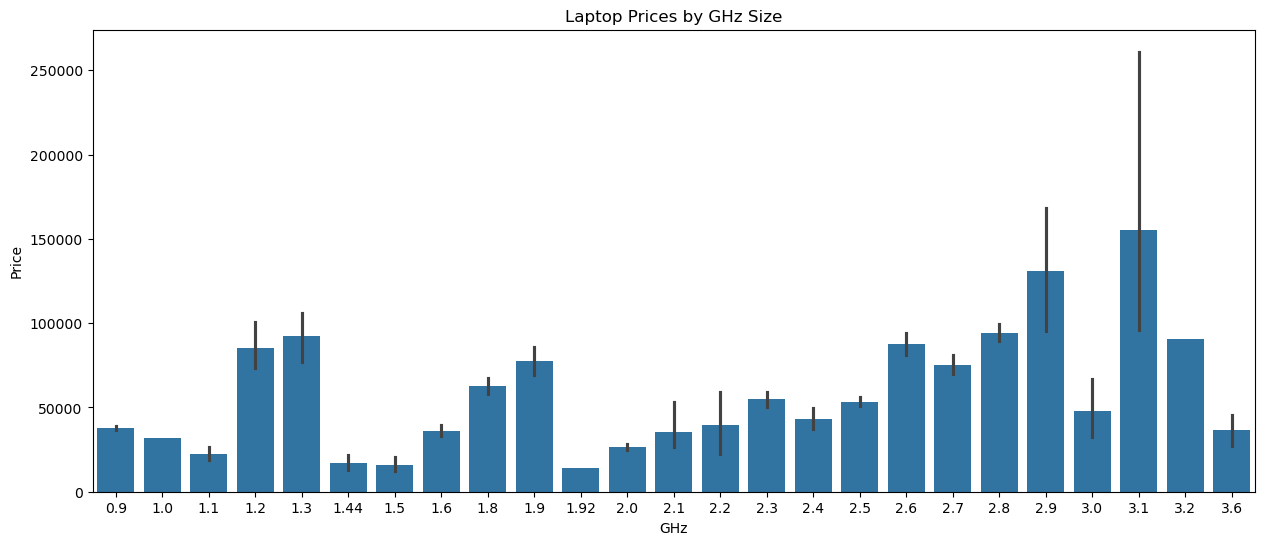

In [58]:
plt.figure(figsize=(15,6))
sns.barplot(x='GHz',y='Price',data=df)
plt.title('Laptop Prices by GHz Size')
plt.show

### Sonuc